# SpiderNet tutorial: HGSOC model training

This notebook trains SpiderNet on **HGSOC** from a processed data folder generated by `spidernet_dataloading_MIdimselection_HGSOC`.


## Before you start

Set `PROCESSED_DATA_DIR` to the folder produced by `spidernet_dataloading_MIdimselection_HGSOC`.

That folder should contain the processed SpiderNet objects used for training, including `SpiderNet_data_pyg_list.pkl`, `LR_list.pkl`, `genenames_train.pkl`, `adata_list.pkl`, and `adata_all.h5ad`. For HGSOC downstream analyses, `metadata_sample.csv` is also recommended.


## 0. Dataset setup

Set the processed-data directory and training hyperparameters.


In [1]:
from pathlib import Path
import json

# Processed data folder
PROCESSED_DATA_DIR = Path("D:/SpiderNet/Results/HGSOC/ProcessedData")

# Output folder for training results
OUTPUT_ROOT = Path("D:/SpiderNet/Results/HGSOC")

SPECIES = "human"

# Training hyperparameters
DIM_ENVIR = 15
N_JOBS = 5
MAX_EPOCH = 20000

VERSION = "V1"

training_setup = {
    "PROCESSED_DATA_DIR": str(PROCESSED_DATA_DIR),
    "OUTPUT_ROOT": str(OUTPUT_ROOT),
    "SPECIES": SPECIES,
    "DIM_ENVIR": DIM_ENVIR,
    "N_JOBS": N_JOBS,
    "MAX_EPOCH": MAX_EPOCH,
    "VERSION": VERSION,
}

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
setup_path = OUTPUT_ROOT / "HGSOC_modeltraining_setup.json"
with open(setup_path, "w", encoding="utf-8") as f:
    json.dump(training_setup, f, indent=2)

print(f"Training setup saved to: {setup_path}")
training_setup


Training setup saved to: D:\SpiderNet\Results\HGSOC\HGSOC_modeltraining_setup.json


{'PROCESSED_DATA_DIR': 'D:\\SpiderNet\\Results\\HGSOC\\ProcessedData',
 'OUTPUT_ROOT': 'D:\\SpiderNet\\Results\\HGSOC',
 'SPECIES': 'human',
 'DIM_ENVIR': 15,
 'N_JOBS': 5,
 'MAX_EPOCH': 20000,
 'VERSION': 'V1'}

## 1. Imports and device setup

In [2]:

import json
from pathlib import Path

import pandas as pd
import scanpy as sc
import torch

from SpiderNet.api import (
    build_model,
    run_training,
    infer_meta_interactions,
    normalize_outputs,
    export_results,
)
from SpiderNet.config import PathConfig, TrainingConfig
from SpiderNet.io import load_processed_data, get_spidernet_pyg_list_path, load_spidernet_pyg_list, spidernet_pyg_list_exists

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


C:\Users\junji\miniconda3\envs\SpiderNet_env\Lib\site-packages\louvain\__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


Using device: cuda


## 2. Check the processed data folder

Verify that the required files for training are present.


In [3]:
from SpiderNet.io import get_spidernet_pyg_list_path, load_spidernet_pyg_list, spidernet_pyg_list_exists

required_training_files = [
    "LR_list.pkl",
    "LR_list_cellchatdb.pkl",
    "LR_meta_cellchatdb.pkl",
    "batch_cell_unique.pkl",
    "batch_cell.pkl",
    "genenames_train.pkl",
    "adata_list.pkl",
    "cellclass_unique.pkl",
    "adata_all.h5ad",
]

recommended_hgsoc_files = [
    "metadata_sample.csv",
    "bundle_summary.json",
]

rows = []
spidernet_pyg_path = get_spidernet_pyg_list_path(PROCESSED_DATA_DIR, must_exist=False)
rows.append({
    "group": "required_for_training",
    "file": "SpiderNet_data_pyg_list.pkl or SpiderNet_data_pyg_list.pt",
    "path": str(spidernet_pyg_path),
    "exists": spidernet_pyg_list_exists(PROCESSED_DATA_DIR),
})
for name in required_training_files:
    path = PROCESSED_DATA_DIR / name
    rows.append({
        "group": "required_for_training",
        "file": name,
        "path": str(path),
        "exists": path.exists(),
    })

for name in recommended_hgsoc_files:
    path = PROCESSED_DATA_DIR / name
    rows.append({
        "group": "recommended_for_hgsoc_downstream",
        "file": name,
        "path": str(path),
        "exists": path.exists(),
    })

status_df = pd.DataFrame(rows)
display(status_df)

missing_required = status_df.loc[
    (status_df["group"] == "required_for_training") & (~status_df["exists"]),
    "file",
].tolist()

if missing_required:
    raise FileNotFoundError(
        "The processed bundle is incomplete. Missing required files: "
        + ", ".join(missing_required)
    )

bundle_summary_path = PROCESSED_DATA_DIR / "bundle_summary.json"
if bundle_summary_path.exists():
    with open(bundle_summary_path, "r", encoding="utf-8") as f:
        bundle_summary = json.load(f)
    print("Found bundle_summary.json")
    display(pd.Series(bundle_summary, name="value"))
else:
    bundle_summary = None
    print("bundle_summary.json not found. Training can still proceed.")

adata_all_path = PROCESSED_DATA_DIR / "adata_all.h5ad"
adata_example = sc.read_h5ad(adata_all_path, backed="r")
overview = pd.Series({
    "processed_dir": str(PROCESSED_DATA_DIR),
    "n_cells_total": int(adata_example.n_obs),
    "n_genes_total": int(adata_example.n_vars),
    "obs_columns": list(adata_example.obs.columns),
    "obsm_keys": list(adata_example.obsm.keys()),
}, name="value")
display(overview.to_frame())
adata_example.file.close()


,group,file,path,exists
0,required_for_training,SpiderNet_data_pyg_list.pkl,D:\SpiderNet\Results\HGSOC\ProcessedData\Spide...,True
1,required_for_training,LR_list.pkl,D:\SpiderNet\Results\HGSOC\ProcessedData\LR_li...,True
2,required_for_training,LR_list_cellchatdb.pkl,D:\SpiderNet\Results\HGSOC\ProcessedData\LR_li...,True
3,required_for_training,LR_meta_cellchatdb.pkl,D:\SpiderNet\Results\HGSOC\ProcessedData\LR_me...,True
4,required_for_training,batch_cell_unique.pkl,D:\SpiderNet\Results\HGSOC\ProcessedData\batch...,True
5,required_for_training,batch_cell.pkl,D:\SpiderNet\Results\HGSOC\ProcessedData\batch...,True
6,required_for_training,genenames_train.pkl,D:\SpiderNet\Results\HGSOC\ProcessedData\genen...,True
7,required_for_training,adata_list.pkl,D:\SpiderNet\Results\HGSOC\ProcessedData\adata...,True
8,required_for_training,cellclass_unique.pkl,D:\SpiderNet\Results\HGSOC\ProcessedData\cellc...,True
9,required_for_training,adata_all.h5ad,D:\SpiderNet\Results\HGSOC\ProcessedData\adata...,True


Found bundle_summary.json


data_path_main                                  D:\SpiderNet\Data\HGSOC
adata_dir                                 D:\SpiderNet\Data\HGSOC\adata
num_input_files                                                      48
num_used_files                                                       48
num_batches                                                          48
num_cells_total                                                  276668
num_genes_all                                                       979
num_genes_train                                                     979
num_lr_pairs_train                                                  185
num_lr_pairs_val                                                      0
config_snapshot       {'adata_folder_name': 'adata', 'file_suffix': ...
Name: value, dtype: object

,value
processed_dir,D:\SpiderNet\Results\HGSOC\ProcessedData
n_cells_total,276668
n_genes_total,979
obs_columns,"[orig.ident, nCount_RNA, nFeature_RNA, samples..."
obsm_keys,[spatial]


## 3. Build training config and run directories

In [4]:
train_cfg = TrainingConfig(
    dim_envir=DIM_ENVIR,
    n_jobs=N_JOBS,
    max_epoch=MAX_EPOCH,
    version=VERSION,
)

paths = PathConfig(
    data_root=PROCESSED_DATA_DIR,
    output_root=OUTPUT_ROOT,
    species=SPECIES,
    version=VERSION,
)

run_dirs = paths.ensure_dirs(dim_envir=train_cfg.dim_envir)
print(run_dirs)

with open(paths.output_root / "run_dirs.json", "w", encoding="utf-8") as handle:
    json.dump({k: str(v) for k, v in run_dirs.items()}, handle, indent=2)

train_cfg


{'run_dir': WindowsPath('D:/SpiderNet/Results/HGSOC/V1/SpiderNet_Result_dim15'), 'model_dir': WindowsPath('D:/SpiderNet/Results/HGSOC/V1/SpiderNet_Result_dim15/Model')}


TrainingConfig(version='V1', dim_envir=15, max_epoch=20000, n_jobs=5, optimizer='adam')

## 4. Load the processed SpiderNet objects

In [5]:

processed = load_processed_data(PROCESSED_DATA_DIR)

print("Processed directory:", PROCESSED_DATA_DIR)
print("Number of batches:", len(processed.spidernet_data))
print("Number of LR pairs:", len(processed.lr_list))
print("Number of training genes:", processed.genenames_train.shape[0])


Processed directory: D:\SpiderNet\Results\HGSOC\ProcessedData
Number of batches: 48
Number of LR pairs: 185
Number of training genes: 979


Check that the loaded objects are internally consistent before training.

In [6]:

summary_rows = []
for i in range(len(processed.adata_list)):
    adata_i = processed.adata_list[i]
    edge_index_max = torch.max(processed.spidernet_data[i]["edge_index"]).cpu().item()
    summary_rows.append(
        {
            "batch_index": i,
            "n_cells": adata_i.n_obs,
            "n_genes": adata_i.n_vars,
            "edge_index_max": edge_index_max,
            "edge_index_matches_n_cells": adata_i.n_obs == (edge_index_max + 1),
        }
    )

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

issues = []
if len(processed.spidernet_data) == 0:
    issues.append("No processed batches were loaded.")
if len(processed.lr_list) == 0:
    issues.append("No ligand-receptor pairs were retained.")
if processed.genenames_train.shape[0] == 0:
    issues.append("No training genes were retained.")
if not summary_df["edge_index_matches_n_cells"].all():
    issues.append("At least one batch has an edge index / cell-count mismatch.")

if issues:
    print("Sanity check flagged the following issues:")
    for issue in issues:
        print("-", issue)
else:
    print("Sanity checks passed. The processed data appear internally consistent.")


,batch_index,n_cells,n_genes,edge_index_max,edge_index_matches_n_cells
0,0,5660,979,5659,True
1,1,8821,979,8820,True
2,2,5295,979,5294,True
3,3,2944,979,2943,True
4,4,6990,979,6989,True
5,5,5944,979,5943,True
6,6,7549,979,7548,True
7,7,7413,979,7412,True
8,8,2212,979,2211,True
9,9,3267,979,3266,True


Sanity checks passed. The processed data appear internally consistent.


## 5. Build and train the SpiderNet model

In [7]:

model = build_model(
    processed=processed,
    train_cfg=train_cfg,
    device=device,
)

print(model)


Number of GPUs available: 1
GPU 0: NVIDIA GeForce RTX 4070
SpiderNet_model(
  (dropout_fun): Dropout(p=0.1, inplace=False)
  (Relu): ReLU()
  (Sigmoid): Sigmoid()
  (enc_factor_envir_pre_receiver): Sequential(
    (0): Linear(in_features=979, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): Tanh()
  )
  (enc_factor_envir_pre_sender): Sequential(
    (0): Linear(in_features=979, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): Tanh()
  )
  (enc_factor_envir): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=15, bias=True)
  )
)


Run model training and save checkpoints.

In [8]:

model = run_training(
    model=model,
    processed=processed,
    train_cfg=train_cfg,
    model_dir=run_dirs["model_dir"],
    device=device,
)


Loading existing trained model...


## 6. Extract inferred meta-interactions and loadings

This step exports:
- MI activities
- LR loadings
- sender loadings
- receiver loadings


In [9]:

results = infer_meta_interactions(model=model, processed=processed)
results = normalize_outputs(results)

print("Factor_envir shape:", results["factor_envir"].shape)
print("LR loading shape:", results["loading_lr"].shape)
print("Receiver loading shape:", results["loading_receiver"].shape)
print("Sender loading shape:", results["loading_sender"].shape)


Factor_envir shape: (2766680, 15)
LR loading shape: (15, 185)
Receiver loading shape: (15, 979)
Sender loading shape: (15, 979)


## 7. Save training outputs

In [10]:

export_results(
    results=results,
    processed=processed,
    precessed_data_dir=PROCESSED_DATA_DIR,
    output_dir=run_dirs["run_dir"],
)

with open(run_dirs["model_dir"] / "SpiderNet_model_config.json", "w", encoding="utf-8") as handle:
    json.dump(train_cfg.to_dict(), handle, indent=2)

provenance = {
    "processed_data_dir": str(PROCESSED_DATA_DIR),
    "output_root": str(OUTPUT_ROOT),
    "run_dir": str(run_dirs["run_dir"]),
    "model_dir": str(run_dirs["model_dir"]),
    "species": SPECIES,
    "dim_envir": DIM_ENVIR,
    "n_jobs": N_JOBS,
    "max_epoch": MAX_EPOCH,
    "version": VERSION,
}

if bundle_summary is not None:
    provenance["processed_bundle_summary_path"] = str(bundle_summary_path)

with open(run_dirs["run_dir"] / "SpiderNet_training_provenance.json", "w", encoding="utf-8") as handle:
    json.dump(provenance, handle, indent=2)

print(f"Results saved to: {run_dirs['run_dir']}")
provenance


Results saved to: D:\SpiderNet\Results\HGSOC\V1\SpiderNet_Result_dim15


{'processed_data_dir': 'D:\\SpiderNet\\Results\\HGSOC\\ProcessedData',
 'output_root': 'D:\\SpiderNet\\Results\\HGSOC',
 'run_dir': 'D:\\SpiderNet\\Results\\HGSOC\\V1\\SpiderNet_Result_dim15',
 'model_dir': 'D:\\SpiderNet\\Results\\HGSOC\\V1\\SpiderNet_Result_dim15\\Model',
 'species': 'human',
 'dim_envir': 15,
 'n_jobs': 5,
 'max_epoch': 20000,
 'version': 'V1',
 'processed_bundle_summary_path': 'D:\\SpiderNet\\Results\\HGSOC\\ProcessedData\\bundle_summary.json'}

## Key output files

Main outputs in `run_dirs["run_dir"]`:

- `Factor_envir_use.npy`
- `loading_LR_use.npy`
- `loading_sender_use.npy`
- `loading_receiver_use.npy`


## Optional downstream analyses

These sections use the processed data in `PROCESSED_DATA_DIR` together with the trained model outputs in `run_dirs["run_dir"]`.


## Optional 1. MI correlation analysis

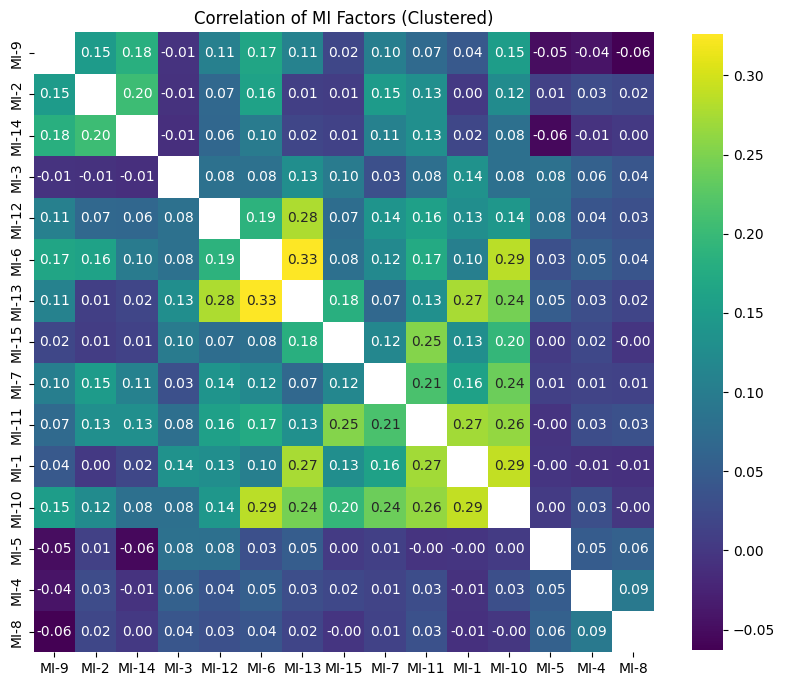

Saved heatmap to D:\SpiderNet\Results\HGSOC\V1\SpiderNet_Result_dim15\MI_correlation_heatmap_clustered.png


In [11]:

from SpiderNet.analysis import MI_correlation

mi_results = MI_correlation(
    run_dirs["run_dir"],
    run_dirs["run_dir"] / "Factor_envir_use.npy",
    show=True,
)


## Optional 2. LR loading-based pathway enrichment

BMP: 4 LR pairs (kept)
CDH1: 1 LR pairs (kept)
COLLAGEN: 63 LR pairs (kept)
EPHA: 2 LR pairs (kept)
EPHB: 10 LR pairs (kept)
FGF: 10 LR pairs (kept)
FN1: 8 LR pairs (kept)
MHC-I: 8 LR pairs (kept)
MHC-II: 7 LR pairs (kept)
IGF: 5 LR pairs (kept)
ACTIVIN: 1 LR pairs (kept)
GALECTIN: 1 LR pairs (kept)
MIF: 1 LR pairs (kept)
SPP1: 7 LR pairs (kept)
THBS: 8 LR pairs (kept)
LIGHT: 2 LR pairs (kept)
VTN: 2 LR pairs (kept)
WNT: 31 LR pairs (kept)
ncWNT: 14 LR pairs (kept)


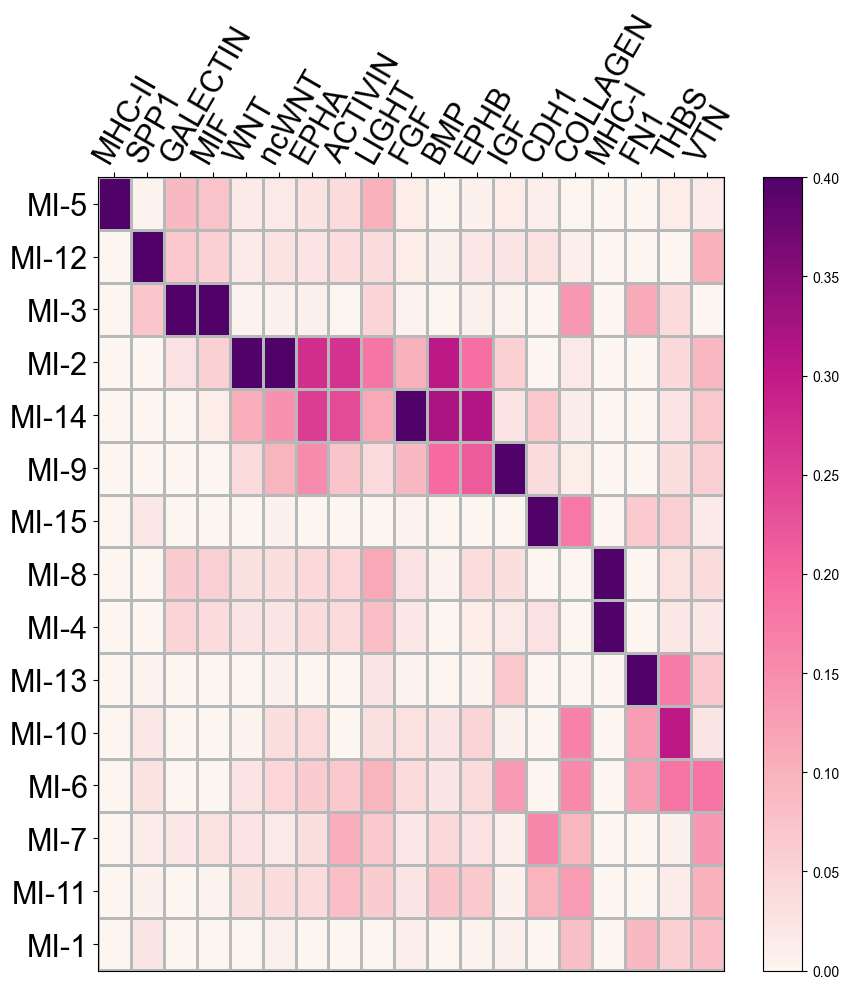

{'loading_LR_use_df':        BMP7 -> ACVR2A  BMP7 -> BMPR1A  BMP7 -> BMPR1A+BMPR2  BMP7 -> BMPR2  \
 MI-1         0.000000        0.000000              0.000000       0.000000   
 MI-2         0.278040        0.709195              0.262248       0.843465   
 MI-3         0.000000        0.000000              0.000000       0.000000   
 MI-4         0.001925        0.000000              0.000000       0.000990   
 MI-5         0.000000        0.000000              0.000000       0.000000   
 MI-6         0.029146        0.000000              0.036325       0.047114   
 MI-7         0.070521        0.061505              0.024818       0.131595   
 MI-8         0.013712        0.000000              0.000000       0.000000   
 MI-9         0.199778        0.558603              0.144781       0.469227   
 MI-10        0.000000        0.044204              0.051670       0.036827   
 MI-11        0.098822        0.171927              0.049100       0.159982   
 MI-12        0.012009        0

In [12]:

from SpiderNet.analysis import LRLoading_enrichment

LRLoading_enrichment(
    loading_LR_use_path=run_dirs["run_dir"] / "loading_LR_use.npy",
    lr_list_path=PROCESSED_DATA_DIR / "LR_list.pkl",
    lr_list_cellchatdb_path=PROCESSED_DATA_DIR / "LR_list_cellchatdb.pkl",
    lr_meta_cellchatdb_path=PROCESSED_DATA_DIR / "LR_meta_cellchatdb.pkl",
    Factor_envir_use_path=run_dirs["run_dir"] / "Factor_envir_use.npy",
    file_savepath_main=run_dirs["run_dir"],
    show=True,
)


## Optional 3. Sender-cell-type--receiver-cell-type interaction analysis

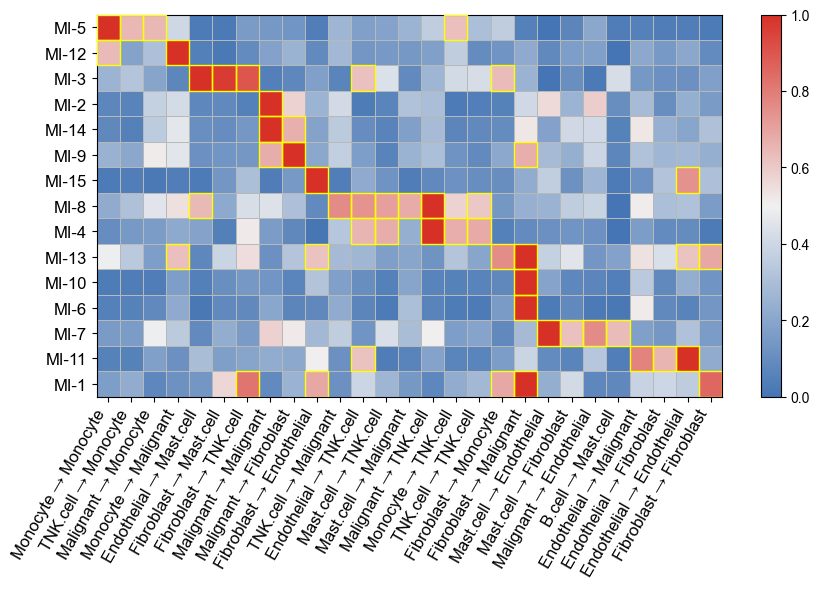

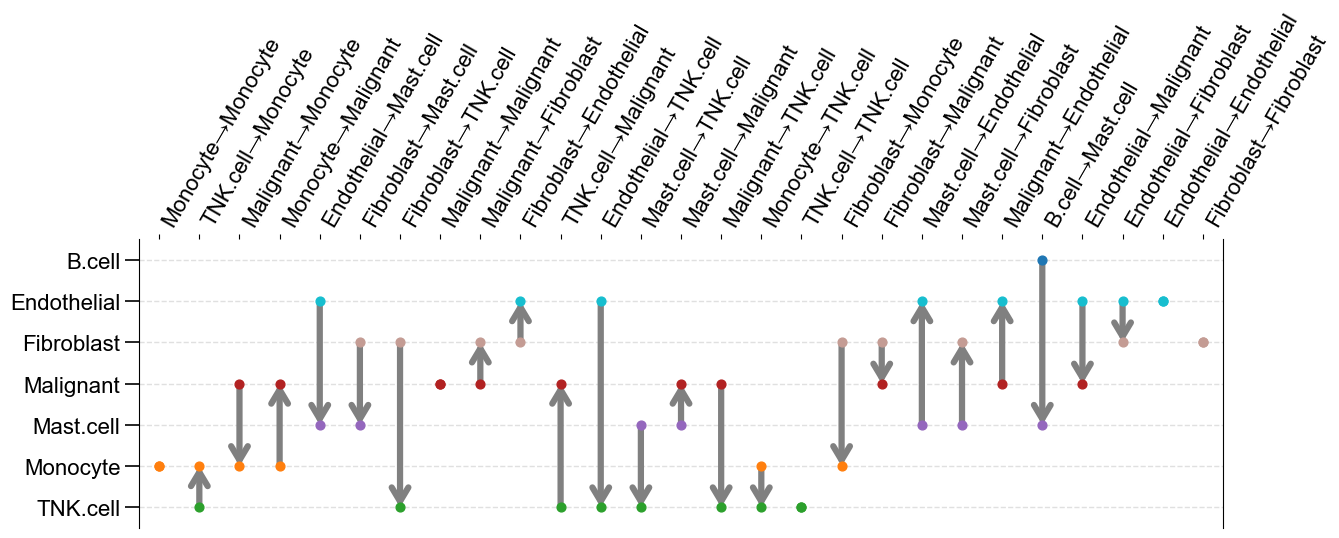

D:\SpiderNet\SpiderNet_proj\SpiderNet_Project\SpiderNet\analysis.py:1076: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.24400588870048523' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  Avg_MI_cellclass_pair_merge_zscored_ctagg_sender.iloc[idx, :] = list(
D:\SpiderNet\SpiderNet_proj\SpiderNet_Project\SpiderNet\analysis.py:1076: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.08094234019517899' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  Avg_MI_cellclass_pair_merge_zscored_ctagg_sender.iloc[idx, :] = list(
D:\SpiderNet\SpiderNet_proj\SpiderNet_Project\SpiderNet\analysis.py:1076: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.42560747265815735' has dtype 

{'Avg_MI_cellclass_pair_merge_use_csv': 'D:\\SpiderNet\\Results\\HGSOC\\V1\\SpiderNet_Result_dim15\\Avg_MI_cellclass_pair_merge_use.csv',
 'Avg_MI_cellclass_pair_png': 'D:\\SpiderNet\\Results\\HGSOC\\V1\\SpiderNet_Result_dim15\\Avg_MI_cellclass_pair.png',
 'Avg_MI_cellclass_pair_onlymalignant_png': 'D:\\SpiderNet\\Results\\HGSOC\\V1\\SpiderNet_Result_dim15\\Avg_MI_cellclass_pair_onlymalignant_highlight.png',
 'Sender_vs_Receiver_scatter_png': 'D:\\SpiderNet\\Results\\HGSOC\\V1\\SpiderNet_Result_dim15\\Sender_vs_Receiver_MI_Strength.png',
 'Celltype_pair_example_png': 'D:\\SpiderNet\\Results\\HGSOC\\V1\\SpiderNet_Result_dim15\\Celltype_pair_example.png',
 'Agg_heatmap_png': 'D:\\SpiderNet\\Results\\HGSOC\\V1\\SpiderNet_Result_dim15\\Avg_MI_cellclass_pair_agg.png',
 'Site_dotplot_png': 'D:\\SpiderNet\\Results\\HGSOC\\V1\\SpiderNet_Result_dim15\\Avg_MI_cellclass_pair_logfc_site_dotplot.png',
 'Site_dotplot_top_hits_csv': 'D:\\SpiderNet\\Results\\HGSOC\\V1\\SpiderNet_Result_dim15\\Avg_MI_c

In [13]:
from SpiderNet.io import get_spidernet_pyg_list_path, load_spidernet_pyg_list, spidernet_pyg_list_exists

from SpiderNet.analysis import MI_Celltypepair_enrichment

MI_Celltypepair_enrichment(
    SpiderNet_data_pyg_list_path=get_spidernet_pyg_list_path(PROCESSED_DATA_DIR),
    Factor_envir_use_path=run_dirs["run_dir"] / "Factor_envir_use.npy",
    file_savepath_main=run_dirs["run_dir"],
    metadata_sample_path=PROCESSED_DATA_DIR / "metadata_sample.csv",
    LR_loading_pathway_path=run_dirs["run_dir"] / "LR_loading_pathway.csv",
    dim_envir=train_cfg.dim_envir,
    MIlevel_agg_threshold=0.6,
    batch_cell_unique_path=PROCESSED_DATA_DIR / "batch_cell_unique.pkl",
    adata_list_path=PROCESSED_DATA_DIR / "adata_list.pkl",
    adata_copy_path=PROCESSED_DATA_DIR / "adata_all.h5ad",
    show=True,
)


## Reuse for other datasets

To adapt this notebook, update:
- `PROCESSED_DATA_DIR`
- training hyperparameters
- optional metadata paths for downstream analyses
- `DIM_ENVIR`


In [26]:
print(len(results['factor_envir_list']))
print(results['factor_envir_list'][0].shape)
type(results['factor_envir_list'][0])
import numpy as np
factor_envir_all = np.vstack(results['factor_envir_list'])

factor_envir_all
##Save the factor_envir_all as csv
import pandas as pd
factor_envir_df = pd.DataFrame(factor_envir_all)
factor_envir_df.columns = [f"MI_{i+1}" for i in range(factor_envir_all.shape[1])]
factor_envir_df.to_csv(run_dirs["run_dir"] / "Factor_envir_all.csv", index=False)

48
(56600, 15)
